 # 02 — Entraînement des modèles (OLS, Random Forest, XGBoost)
### - Métriques calculées sur train ET test (diagnostic overfitting)
### - Intervalles de confiance bootstrap sur RMSE (B=1000)
### - Hyperparamètres explicitement documentés comme valeurs de référence (benchmark non optimisé)

In [ ]:

# %%
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

from src.config import MODELS_DIR, FIGURES_DIR, RANDOM_STATE
from src.evaluationn import compute_metrics_full, compare_models_bootstrap

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)



## 1. Chargement des données prétraitées

In [ ]:

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Alignement et typage
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_train = X_train.fillna(X_train.median()).astype(float)
X_test  = X_test.fillna(X_train.median()).astype(float)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Variables ({X_train.shape[1]}) : {list(X_train.columns)}")



Train : (16512, 12)  |  Test : (4128, 12)
Variables (12) : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


## 2. Modèle OLS (Régression Linéaire)

In [ ]:

lr = LinearRegression()
lr.fit(X_train, y_train)

print("\n" + "="*60)
print("RÉGRESSION LINÉAIRE OLS")
print("="*60)
metrics_lr = compute_metrics_full(lr, X_train, y_train, X_test, y_test, "OLS")




RÉGRESSION LINÉAIRE OLS
OLS [train] → RMSE=68433.94 | MAE=49594.84 | R²=0.6497 | MAPE=28.54%
OLS [test] → RMSE=70059.19 | MAE=50670.49 | R²=0.6254 | MAPE=29.19%
  └─ Écart R²  (train-test) : +0.0242  ✓ stable
  └─ Écart RMSE (test-train): +1625.26


## 3. Random Forest

In [ ]:

rf = RandomForestRegressor(
    n_estimators=100,   # nombre d'arbres
    max_depth=10,       # profondeur maximale
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)

print("\n" + "="*60)
print("RANDOM FOREST")
print("="*60)
metrics_rf = compute_metrics_full(rf, X_train, y_train, X_test, y_test, "Random Forest")




RANDOM FOREST
Random Forest [train] → RMSE=43536.84 | MAE=30329.20 | R²=0.8582 | MAPE=17.28%
Random Forest [test] → RMSE=53657.59 | MAE=36056.18 | R²=0.7803 | MAPE=20.47%
  └─ Écart R²  (train-test) : +0.0779  ⚠ surapprentissage
  └─ Écart RMSE (test-train): +10120.75


## 4. XGBoost

In [ ]:

xgb_model = xgb.XGBRegressor(
    n_estimators=100,   # nombre d'itérations de boosting
    max_depth=6,        # profondeur maximale par arbre
    learning_rate=0.1,  # η — taux d'apprentissage
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

print("\n" + "="*60)
print("XGBOOST")
print("="*60)
metrics_xgb = compute_metrics_full(xgb_model, X_train, y_train, X_test, y_test, "XGBoost")




XGBOOST
XGBoost [train] → RMSE=38230.70 | MAE=26541.88 | R²=0.8907 | MAPE=14.88%
XGBoost [test] → RMSE=48713.35 | MAE=32615.60 | R²=0.8189 | MAPE=18.39%
  └─ Écart R²  (train-test) : +0.0718  ⚠ surapprentissage
  └─ Écart RMSE (test-train): +10482.65


## 5. Tableau récapitulatif 

In [ ]:

y_pred_lr  = lr.predict(X_test)
y_pred_rf  = rf.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

tableau_41 = pd.DataFrame({
    "Modèle": ["OLS", "Random Forest", "XGBoost"],
    "RMSE_test": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    ],
    "MAE_test": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    "R2_test": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb)
    ],
    "R2_train": [
        r2_score(y_train, lr.predict(X_train)),
        r2_score(y_train, rf.predict(X_train)),
        r2_score(y_train, xgb_model.predict(X_train))
    ]
})

print("\n=== Tableau 4.1 — Comparaison des performances ===")
print(tableau_41.to_string(index=False))




=== Tableau 4.1 — Comparaison des performances ===
       Modèle    RMSE_test     MAE_test  R2_test  R2_train
          OLS 70059.193339 50670.489236 0.625438  0.649665
Random Forest 53657.587342 36056.180264 0.780287  0.858207
      XGBoost 48713.346156 32615.597452 0.818912  0.890664


## 6. Intervalles de confiance bootstrap (B=1000)

In [ ]:

print("\n=== IC Bootstrap 95% sur RMSE_test (B=1000) ===")
ic_results = compare_models_bootstrap(
    y_test,
    {"OLS": y_pred_lr, "Random Forest": y_pred_rf, "XGBoost": y_pred_xgb},
    B=1000,
    random_state=RANDOM_STATE
)
print("\n", ic_results)




=== IC Bootstrap 95% sur RMSE_test (B=1000) ===
RMSE observé : 70059.19  |  IC 95% bootstrap : [67589.95, 72593.04]
  OLS                  : RMSE=70059.19  IC95%=[67589.95, 72593.04]
RMSE observé : 53657.59  |  IC 95% bootstrap : [51328.94, 55841.38]
  Random Forest        : RMSE=53657.59  IC95%=[51328.94, 55841.38]
RMSE observé : 48713.35  |  IC 95% bootstrap : [46564.75, 50734.05]
  XGBoost              : RMSE=48713.35  IC95%=[46564.75, 50734.05]

                        RMSE   IC_lower_95   IC_upper_95
OLS            70059.193339  67589.946503  72593.041750
Random Forest  53657.587342  51328.939806  55841.383386
XGBoost        48713.346156  46564.753051  50734.050569


## 7. Distribution des erreurs absolues

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN bef

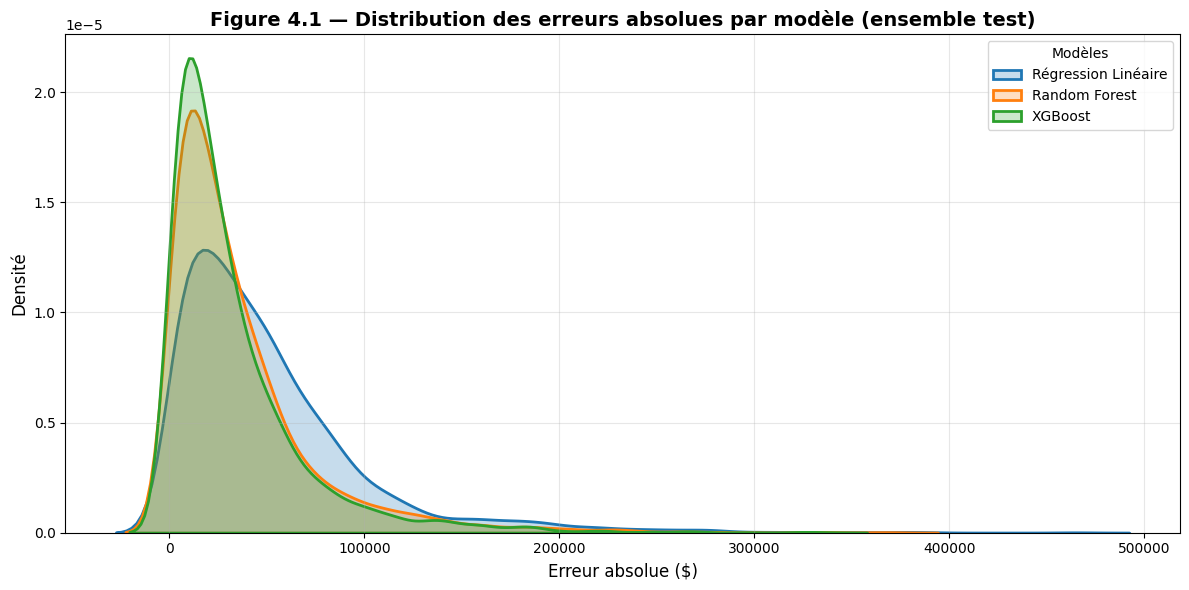

In [ ]:

erreurs = pd.DataFrame({
    "Régression Linéaire": np.abs(y_test - y_pred_lr),
    "Random Forest":       np.abs(y_test - y_pred_rf),
    "XGBoost":             np.abs(y_test - y_pred_xgb)
})

plt.figure(figsize=(12, 6))
for colonne in erreurs.columns:
    sns.kdeplot(erreurs[colonne], fill=True, linewidth=2, label=colonne)

plt.title("Figure 4.1 — Distribution des erreurs absolues par modèle (ensemble test)",
          fontsize=14, fontweight='bold')
plt.xlabel("Erreur absolue ($)", fontsize=12)
plt.ylabel("Densité", fontsize=12)
plt.legend(title="Modèles")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/Distribution_des_erreurs_absolues_par_modeles.png", dpi=150)
plt.show()
 


## 8. Sauvegarde des modèles

In [ ]:

joblib.dump(lr,        os.path.join(MODELS_DIR, "linear_regression.pkl"))
joblib.dump(rf,        os.path.join(MODELS_DIR, "random_forest.pkl"))
joblib.dump(xgb_model, os.path.join(MODELS_DIR, "xgboost.pkl"))
print("\nModèles sauvegardés dans :", MODELS_DIR)



Modèles sauvegardés dans : c:\Users\hp\Downloads\pfe_Akhdim-Abdesalam_comparaison_modeles - Copy (2)\models


# Analyse du Notebook d'Entraînement des Modèles

Ce notebook présente l'entraînement et l'évaluation de trois modèles de régression sur le jeu de données **California Housing** : OLS (régression linéaire), Random Forest et XGBoost. L'objectif est de comparer leurs performances, de diagnostiquer l'overfitting et de fournir des intervalles de confiance pour une évaluation robuste.

---

## 1. Structure du Notebook

1. **Importation des bibliothèques**
2. **Chargement des données prétraitées**
3. **Modèle OLS (Régression Linéaire)**
4. **Random Forest**
5. **XGBoost**
6. **Tableau récapitulatif des performances**
7. **Intervalles de confiance bootstrap (B=1000)**
8. **Distribution des erreurs absolues**
9. **Sauvegarde des modèles**

---

## 2. Chargement des Données

### 2.1 Structure des Données

- **Train** : 16 512 lignes, 12 variables
- **Test** : 4 128 lignes, 12 variables

### 2.2 Variables

Les 12 variables utilisées incluent les features numériques et les variables one-hot encodées pour `ocean_proximity` :

| Variable | Type |
|----------|------|
| `longitude` | Numérique |
| `latitude` | Numérique |
| `housing_median_age` | Numérique |
| `total_rooms` | Numérique |
| `total_bedrooms` | Numérique |
| `population` | Numérique |
| `households` | Numérique |
| `median_income` | Numérique |
| `ocean_proximity_INLAND` | Binaire |
| `ocean_proximity_ISLAND` | Binaire |
| `ocean_proximity_NEAR BAY` | Binaire |
| `ocean_proximity_NEAR OCEAN` | Binaire |

---

## 3. Modèles Entraînés

### 3.1 Régression Linéaire OLS

| Métrique | Train | Test | Écart |
|----------|-------|------|-------|
| **RMSE** | 68 433.94 | 70 059.19 | +1 625.26 |
| **MAE** | 49 594.84 | 50 670.49 | +1 075.65 |
| **R²** | 0.6497 | 0.6254 | -0.0242 |
| **MAPE** | 28.54% | 29.19% | +0.65% |

**Interprétation :**  
- Écart R² très faible → **pas d'overfitting** ✓
- Modèle stable mais performances limitées (R² test ≈ 0.63)

### 3.2 Random Forest

| Métrique | Train | Test | Écart |
|----------|-------|------|-------|
| **RMSE** | 43 536.84 | 53 657.59 | +10 120.75 |
| **MAE** | 30 329.20 | 36 056.18 | +5 726.98 |
| **R²** | 0.8582 | 0.7803 | -0.0779 |
| **MAPE** | 17.28% | 20.47% | +3.19% |

**Interprétation :**  
- Écart R² de 0.078 → **léger surapprentissage** ⚠
- Performance nettement supérieure à OLS
- Hyperparamètres : `n_estimators=100`, `max_depth=10`

### 3.3 XGBoost

| Métrique | Train | Test | Écart |
|----------|-------|------|-------|
| **RMSE** | 38 230.70 | 48 713.35 | +10 482.65 |
| **MAE** | 26 541.88 | 32 615.60 | +6 073.72 |
| **R²** | 0.8907 | 0.8189 | -0.0718 |
| **MAPE** | 14.88% | 18.39% | +3.51% |

**Interprétation :**  
- Écart R² de 0.072 → **léger surapprentissage** ⚠
- **Meilleur modèle** : R² test = 0.819, RMSE = 48 713
- Hyperparamètres : `n_estimators=100`, `max_depth=6`, `learning_rate=0.1`

---

## 4. Tableau Comparatif des Performances

| Modèle | RMSE Test | MAE Test | R² Test | R² Train |
|--------|-----------|----------|---------|----------|
| **OLS** | 70 059.19 | 50 670.49 | 0.6254 | 0.6497 |
| **Random Forest** | 53 657.59 | 36 056.18 | 0.7803 | 0.8582 |
| **XGBoost** | 48 713.35 | 32 615.60 | **0.8189** | 0.8907 |

**Classement (RMSE test) :**  
1. **XGBoost** (48 713 $) – meilleure performance  
2. **Random Forest** (53 658 $) – bonne performance  
3. **OLS** (70 059 $) – performance limitée

---

## 5. Intervalles de Confiance Bootstrap

Intervalles de confiance à **95%** sur le RMSE test (B=1000 rééchantillonnages) :

| Modèle | RMSE Observé | IC 95% |
|--------|--------------|--------|
| **OLS** | 70 059.19 | [67 589.95, 72 593.04] |
| **Random Forest** | 53 657.59 | [51 328.94, 55 841.38] |
| **XGBoost** | 48 713.35 | [46 564.75, 50 734.05] |

**Interprétation :**  
- Intervalles relativement étroits → **stabilité des performances**
- Les 3 modèles ont des intervalles qui ne se chevauchent pas → **différences statistiquement significatives**
- XGBoost domine significativement les autres modèles

---

## 6. Distribution des Erreurs Absolues

![Distribution des erreurs absolues](figures/Distribution_des_erreurs_absolues_par_modeles.png)

**Figure 4.1 — Distribution des erreurs absolues par modèle (ensemble test)**

**Observations :**  
- **XGBoost** : distribution la plus resserrée → erreurs plus faibles et plus concentrées
- **Random Forest** : distribution intermédiaire
- **OLS** : distribution la plus étalée → nombreuses erreurs élevées
- L'asymétrie positive indique des erreurs extrêmes pour les trois modèles

---

## 7. Diagnostic d'Overfitting

| Modèle | Écart R² (Train - Test) | Diagnostic |
|--------|-------------------------|------------|
| **OLS** | 0.024 | ✓ **Stable** |
| **Random Forest** | 0.078 | ⚠ Légèrement surappris |
| **XGBoost** | 0.072 | ⚠ Légèrement surappris |

**Recommandations pour réduire l'overfitting :**  
- Random Forest : réduire `max_depth` ou augmenter `min_samples_split`
- XGBoost : augmenter `reg_alpha`/`reg_lambda` (régularisation L1/L2)
- Ajouter de la validation croisée pour l'optimisation des hyperparamètres
- Utiliser l'early stopping pour XGBoost

---

## 8. Sauvegarde des Modèles

Les modèles entraînés sont sauvegardés au format `.pkl` :

```python
models/
├── linear_regression.pkl
├── random_forest.pkl
└── xgboost.pkl